In [3]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Path to dataset files: /kaggle/input/cifake-real-and-ai-generated-synthetic-images


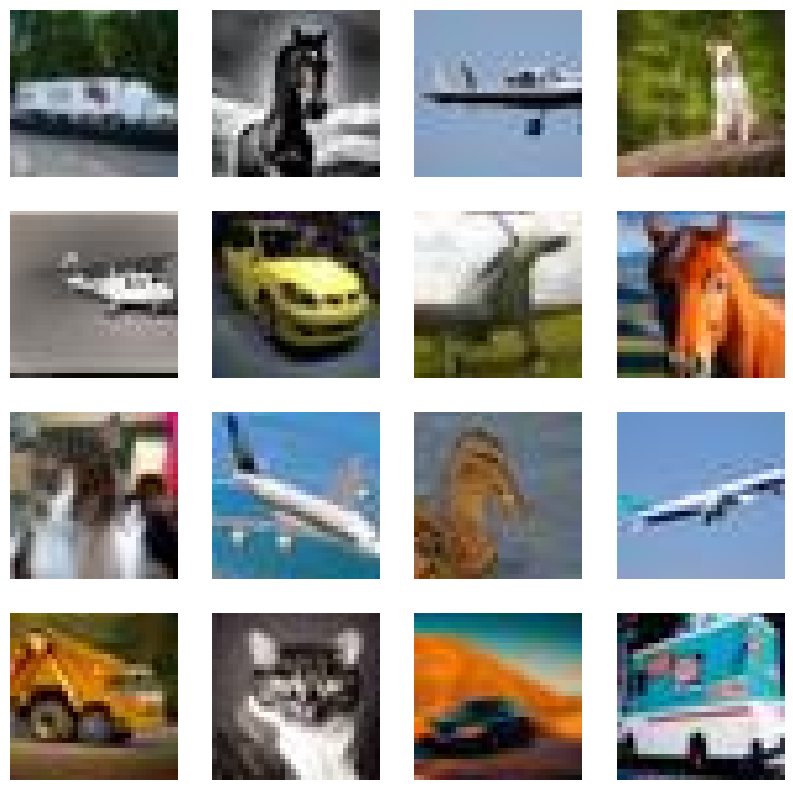

In [18]:
import glob
import random

folder=path+'/'
paths=glob.glob(folder+"*/*/*.jpg")
_, axes = plt.subplots(4, 4, figsize=(10, 10))
random.shuffle(paths)
for ax, img_path in zip(axes.flatten(), paths):
    ax.imshow(Image.open(img_path))
    ax.axis("off")

In [4]:
# Set device (GPU support for Mac M-series or NVIDIA)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
# Configuration
CONFIG = {
    "ROOT_DIR": path,
    "BATCH_SIZE": 32,
    "IMG_SIZE": 224,
    "NUM_WORKERS": 2
}

# Define Transforms (Normalization required for pre-trained models)
data_transforms = {

    'train': transforms.Compose([
        transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])), # 224x224
        transforms.RandomHorizontalFlip(), # Augmentation
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        # mean and std of imagenet dataset, to utilize the pre-learned weights of these models
    ]),

    'test': transforms.Compose([
        transforms.Resize((CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'])),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print(f"Configuration: {CONFIG}")

Configuration: {'ROOT_DIR': '/kaggle/input/cifake-real-and-ai-generated-synthetic-images', 'BATCH_SIZE': 32, 'IMG_SIZE': 224, 'NUM_WORKERS': 2}
{'ROOT_DIR': '/kaggle/input/cifake-real-and-ai-generated-synthetic-images', 'BATCH_SIZE': 32, 'IMG_SIZE': 224, 'NUM_WORKERS': 2}


In [9]:
class CIFAKEDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get Path
        img_name = self.dataframe.iloc[idx, 0]
        img_path = os.path.join(self.root_dir, img_name)

        # 2. Get Label
        label = int(self.dataframe.iloc[idx, 1])

        # Load Image
        image = Image.open(img_path).convert('RGB')

        # try:
        #   image = Image.open(img_path).convert('RGB')
        # except (IOError, FileNotFoundError):
        #     # Fallback for testing without data: generate black image
        #     print(f"Image not found: {img_path}")
        #     # image = Image.new('RGB', (224, 224))

        if self.transform:
            image = self.transform(image)

        return image, label

Data Loaded. Train size: 200, Test size: 50


In [24]:
import glob

# Construct the path to search for JPG files within the dataset root
# The 'path' variable is already defined from a previous cell.
image_files = glob.glob(f"{path}/**/*.jpg", recursive=True)

In [25]:
print("\nFirst 5 image files:")
for file in image_files[:5]:
    print(f"- {file}")

print("\nLast 5 image files:")
for file in image_files[-5:]:
    print(f"- {file}")


First 5 image files:
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/943 (5).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/534 (7).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/81 (2).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/869 (9).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/610 (10).jpg

Last 5 image files:
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/3825 (8).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/1400 (9).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/1375 (7).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/1906 (8).jpg
- /kaggle/input/cifake-real-and-ai-generated-synthetic-images/train/REAL/3429 (5).jpg


In [26]:
def build_dataframe(root_dir, split):

    data = []
    classes = {'REAL': 0, 'FAKE': 1}

    split_path = os.path.join(root_dir, split) # root/train, root/test

    for class_name, label in classes.items():
        class_path = os.path.join(split_path, class_name)

        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                # train/REAL/img1.jpg
                relative_path = os.path.join(split, class_name, img_name)
                data.append({'filename': relative_path, 'label': label})

    df = pd.DataFrame(data)
    return df.sample(frac=1).reset_index(drop=True) # Shuffle

In [28]:
xyz = build_dataframe(CONFIG['ROOT_DIR'], 'train')
print(xyz)

                      filename  label
0      train/REAL/0508 (6).jpg      0
1      train/FAKE/4144 (6).jpg      1
2      train/REAL/2586 (2).jpg      0
3      train/FAKE/1852 (3).jpg      1
4      train/REAL/0562 (5).jpg      0
...                        ...    ...
99995  train/REAL/2511 (7).jpg      0
99996  train/REAL/3079 (4).jpg      0
99997  train/FAKE/5195 (6).jpg      1
99998  train/FAKE/2060 (7).jpg      1
99999  train/FAKE/4990 (6).jpg      1

[100000 rows x 2 columns]


In [30]:
# Load DataFrames
print("Scanning dataset directories...")

train_df = build_dataframe(CONFIG['ROOT_DIR'], 'train')
test_df = build_dataframe(CONFIG['ROOT_DIR'], 'test')

print(f"Training Set: {len(train_df)} images")
print(f"Testing Set: {len(test_df)} images")

# 5. Create Loaders (Uses the CIFAKEDataset class defined in previous steps)
datasets = {
    'train': CIFAKEDataset(train_df, CONFIG['ROOT_DIR'], transform=data_transforms['train']),
    'test': CIFAKEDataset(test_df, CONFIG['ROOT_DIR'], transform=data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(datasets['train'], batch_size=CONFIG['BATCH_SIZE'], shuffle=(True), num_workers=CONFIG['NUM_WORKERS']),
    'test': DataLoader(datasets['test'], batch_size=CONFIG['BATCH_SIZE'], shuffle=(False), num_workers=CONFIG['NUM_WORKERS'])
}

print("Dataloaders ready.")

Scanning dataset directories...
Training Set: 100000 images
Testing Set: 20000 images
Dataloaders ready.


In [31]:
def initialize_model(model_name, num_classes=2, feature_extract=True):
    model = None
    weights = 'DEFAULT' # Use best available pre-trained weights

    print(f"Initializing {model_name}...")

    if model_name == "resnet50":
        model = models.resnet50(weights=weights)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=weights)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    elif model_name == "vit":
        model = models.vit_b_16(weights=weights)
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, num_classes)

    return model.to(device)

In [32]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=5):
    since = time.time()

    val_acc_history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'test' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if phase == 'test':
                val_acc_history.append(epoch_acc.cpu().item())

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)

    return model, val_acc_history, time_elapsed

In [34]:
# Define architectures to compare
# models_to_test = ["resnet50", "efficientnet_b0", "vit"]
models_to_test = ["resnet50"]
results = {}

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=3)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing resnet50...

--- Training resnet50 ---
Epoch 1/3
----------
train Loss: 0.2000 Acc: 0.9207
test Loss: 0.1367 Acc: 0.9475
Epoch 2/3
----------
train Loss: 0.1500 Acc: 0.9418
test Loss: 0.1174 Acc: 0.9560
Epoch 3/3
----------
train Loss: 0.1295 Acc: 0.9500
test Loss: 0.1321 Acc: 0.9524
Training complete in 51m 3s
Best val Acc: 0.956000


In [35]:
# Define architectures to compare
models_to_test = ["efficientnet_b0"]

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=3)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing efficientnet_b0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 155MB/s]



--- Training efficientnet_b0 ---
Epoch 1/3
----------
train Loss: 0.1515 Acc: 0.9415
test Loss: 0.0989 Acc: 0.9636
Epoch 2/3
----------
train Loss: 0.1002 Acc: 0.9621
test Loss: 0.0896 Acc: 0.9689
Epoch 3/3
----------
train Loss: 0.0842 Acc: 0.9686
test Loss: 0.0719 Acc: 0.9730
Training complete in 27m 25s
Best val Acc: 0.972950


In [ ]:
# Define architectures to compare
models_to_test = ["vit"]

for model_name in models_to_test:
    # 1. Initialize
    model = initialize_model(model_name)

    # 2. Define Optimizer & Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    # 3. Train & Time
    print(f"\n--- Training {model_name} ---")
    trained_model, history, duration = train_model(model, dataloaders, criterion, optimizer, num_epochs=3)

    # 4. Store Results
    results[model_name] = {
        "model": trained_model,
        "history": history,
        "training_time": duration
    }

Initializing vit...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 68.3MB/s]



--- Training vit ---
Epoch 1/3
----------


In [ ]:
def evaluate_metrics(model, dataloader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    # Inference Loop
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Compute Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='binary')
    rec = recall_score(all_labels, all_preds, average='binary')
    f1 = f1_score(all_labels, all_preds, average='binary')

    return [acc, prec, rec, f1]

# Compare all models
metrics_df = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1 Score"])

for name, data in results.items():
    metrics = evaluate_metrics(data['model'], dataloaders['test'], name)
    metrics_df.loc[name] = metrics

print("\n--- Final Comparative Benchmarks ---")
display(metrics_df)

# Plot Training Comparison
plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data['history'], label=name)
plt.title("Validation Accuracy vs. Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
def predict_image(model, image_path):
    model.eval()
    # Transform image
    img = Image.open(image_path).convert('RGB')
    img_t = data_transforms['test'](img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        _, predicted_class = torch.max(outputs, 1)

    class_names = ['Real', 'AI-Generated']
    confidence = probabilities[predicted_class].item()

    print(f"Prediction: {class_names[predicted_class]} ({confidence*100:.2f}% confidence)")
    # plt.imshow(img)
    # plt.show()

# Example Usage (Change path to a real image)
# predict_image(results['efficientnet_b0']['model'], "test_image.jpg")